In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import time

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix
)

print("EXP-05: Frame and Hop Analysis")

EXP-05: Frame and Hop Analysis


In [2]:
import io
import soundfile as sf

from itertools import islice
from datasets import load_dataset, Audio

dataset = load_dataset(
    "guynich/librispeech_asr_test_vad",
    split="test.clean",
    streaming=True
)

dataset = dataset.cast_column(
    "audio",
    Audio(decode=False)
)

samples = list(islice(dataset, 30))

records = []

for sample in samples:

    audio_data = sample["audio"]

    if audio_data["bytes"] is not None:
        signal, sr = sf.read(
            io.BytesIO(audio_data["bytes"])
        )
    else:
        signal, sr = sf.read(
            audio_data["path"]
        )

    if signal.ndim > 1:
        signal = signal.mean(axis=1)

    records.append({
        "file": sample["file"],
        "speaker_id": sample["speaker_id"],
        "signal": signal,
        "sr": sr,
        "reference": np.asarray(
            sample["speech"],
            dtype=int
        ),
        "confidence": np.asarray(
            sample["confidence"],
            dtype=int
        )
    })

development_records = records[:15]
evaluation_records = records[15:]

print("Toplam kayıt:", len(records))
print("Development:", len(development_records))
print("Evaluation:", len(evaluation_records))

c:\Users\Esma Nur Mantı\Desktop\vad-research\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Toplam kayıt: 30
Development: 15
Evaluation: 15


In [3]:
configurations = [
    (10, 5),
    (15, 5),
    (20, 10),
    (25, 10),
    (30, 10),
    (40, 20)
]

threshold = 0.005

print("Test edilecek kombinasyonlar:")

for frame_ms, hop_ms in configurations:
    print(
        f"Frame: {frame_ms} ms | "
        f"Hop: {hop_ms} ms"
    )

Test edilecek kombinasyonlar:
Frame: 10 ms | Hop: 5 ms
Frame: 15 ms | Hop: 5 ms
Frame: 20 ms | Hop: 10 ms
Frame: 25 ms | Hop: 10 ms
Frame: 30 ms | Hop: 10 ms
Frame: 40 ms | Hop: 20 ms


In [4]:
def calculate_rms(
    signal,
    sr,
    frame_ms,
    hop_ms
):

    frame_length = int(
        sr * frame_ms / 1000
    )

    hop_length = int(
        sr * hop_ms / 1000
    )

    rms_values = librosa.feature.rms(
        y=signal,
        frame_length=frame_length,
        hop_length=hop_length,
        center=False
    )[0]

    rms_times = (
        np.arange(len(rms_values)) * hop_length
        + frame_length / 2
    ) / sr

    return rms_values, rms_times

In [5]:
def evaluate_configuration(
    record,
    frame_ms,
    hop_ms,
    threshold
):

    signal = record["signal"]
    sr = record["sr"]

    reference = record["reference"]
    confidence = record["confidence"]

    start_time = time.perf_counter()

    rms_values, rms_times = calculate_rms(
        signal,
        sr,
        frame_ms,
        hop_ms
    )

    prediction = (
        rms_values > threshold
    ).astype(int)

    elapsed = time.perf_counter() - start_time

    reference_times = (
        np.arange(len(reference)) + 0.5
    ) * 0.032

    indices = np.abs(
        rms_times[:, None]
        - reference_times[None, :]
    ).argmin(axis=0)

    aligned_prediction = prediction[indices]

    valid = confidence == 1

    y_true = reference[valid]
    y_pred = aligned_prediction[valid]

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    return {
        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "Processing Time": elapsed,
        "Frame Count": len(rms_values)
    }

In [6]:
experiment_results = []

for frame_ms, hop_ms in configurations:

    metrics = []

    for record in development_records:

        result = evaluate_configuration(
            record,
            frame_ms,
            hop_ms,
            threshold
        )

        metrics.append(result)

    experiment_results.append({
        "Frame (ms)": frame_ms,
        "Hop (ms)": hop_ms,

        "Mean Precision": np.mean([
            m["Precision"] for m in metrics
        ]),

        "Mean Recall": np.mean([
            m["Recall"] for m in metrics
        ]),

        "Mean F1": np.mean([
            m["F1"] for m in metrics
        ]),

        "Total FP": sum(
            m["FP"] for m in metrics
        ),

        "Total FN": sum(
            m["FN"] for m in metrics
        ),

        "Mean Processing Time (ms)":
            np.mean([
                m["Processing Time"]
                for m in metrics
            ]) * 1000,

        "Total Frames": sum(
            m["Frame Count"]
            for m in metrics
        )
    })

frame_hop_df = pd.DataFrame(
    experiment_results
)

print(
    frame_hop_df.round(4).to_string(index=False)
)

 Frame (ms)  Hop (ms)  Mean Precision  Mean Recall  Mean F1  Total FP  Total FN  Mean Processing Time (ms)  Total Frames
         10         5          0.9465       0.9256   0.9350       110       233                   360.2682         23880
         15         5          0.9456       0.9295   0.9367       113       217                     1.2030         23865
         20        10          0.9483       0.9354   0.9412       111       200                     0.7762         11928
         25        10          0.9488       0.9413   0.9445       111       183                     0.7444         11922
         30        10          0.9501       0.9557   0.9524       110       148                     0.8273         11913
         40        20          0.9494       0.9657   0.9570       111       123                     0.6795          5954


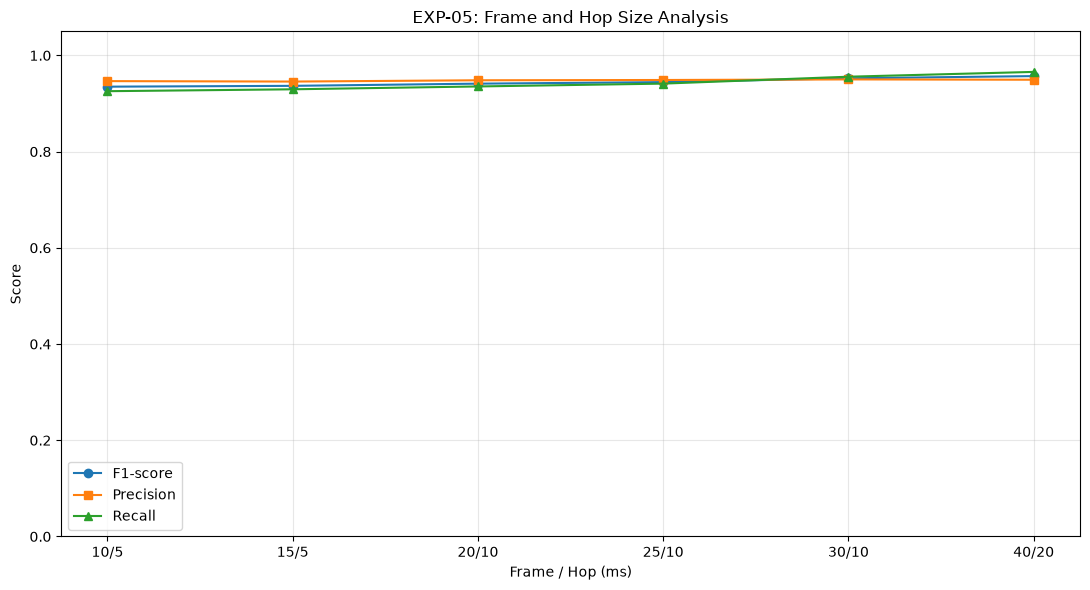

In [7]:
labels = [
    f"{f}/{h}"
    for f, h in configurations
]

plt.figure(figsize=(11, 6))

plt.plot(
    labels,
    frame_hop_df["Mean F1"],
    marker="o",
    label="F1-score"
)

plt.plot(
    labels,
    frame_hop_df["Mean Precision"],
    marker="s",
    label="Precision"
)

plt.plot(
    labels,
    frame_hop_df["Mean Recall"],
    marker="^",
    label="Recall"
)

plt.title(
    "EXP-05: Frame and Hop Size Analysis"
)

plt.xlabel("Frame / Hop (ms)")
plt.ylabel("Score")

plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [8]:
def add_noise(signal, snr_db, seed=42):

    rng = np.random.default_rng(seed)

    noise = rng.normal(0, 1, len(signal))

    signal_power = np.mean(signal ** 2)
    noise_power = np.mean(noise ** 2)

    target_noise_power = signal_power / (
        10 ** (snr_db / 10)
    )

    noise = noise * np.sqrt(
        target_noise_power / noise_power
    )

    return signal + noise

In [9]:
noise_conditions = ["Clean", "20 dB", "10 dB", "0 dB"]

noisy_records = []

for record in development_records:

    signal = record["signal"]

    signals = {
        "Clean": signal,
        "20 dB": add_noise(signal, 20),
        "10 dB": add_noise(signal, 10),
        "0 dB": add_noise(signal, 0)
    }

    noisy_records.append({
        **record,
        "signals": signals
    })

print("Hazırlanan kayıt sayısı:", len(noisy_records))

Hazırlanan kayıt sayısı: 15


In [10]:
noise_results = []

for condition in noise_conditions:

    for frame_ms, hop_ms in configurations:

        metrics = []

        for record in noisy_records:

            test_record = {
                **record,
                "signal": record["signals"][condition]
            }

            result = evaluate_configuration(
                test_record,
                frame_ms,
                hop_ms,
                threshold=0.005
            )

            metrics.append(result)

        noise_results.append({
            "Condition": condition,
            "Frame (ms)": frame_ms,
            "Hop (ms)": hop_ms,

            "Mean Precision": np.mean([
                m["Precision"] for m in metrics
            ]),

            "Mean Recall": np.mean([
                m["Recall"] for m in metrics
            ]),

            "Mean F1": np.mean([
                m["F1"] for m in metrics
            ]),

            "Total FP": sum(
                m["FP"] for m in metrics
            ),

            "Total FN": sum(
                m["FN"] for m in metrics
            )
        })

noise_df = pd.DataFrame(noise_results)

print(
    noise_df.round(3).to_string(index=False)
)

Condition  Frame (ms)  Hop (ms)  Mean Precision  Mean Recall  Mean F1  Total FP  Total FN
    Clean          10         5           0.947        0.926    0.935       110       233
    Clean          15         5           0.946        0.930    0.937       113       217
    Clean          20        10           0.948        0.935    0.941       111       200
    Clean          25        10           0.949        0.941    0.944       111       183
    Clean          30        10           0.950        0.956    0.952       110       148
    Clean          40        20           0.949        0.966    0.957       111       123
    20 dB          10         5           0.924        0.954    0.937       159       131
    20 dB          15         5           0.925        0.957    0.940       164       123
    20 dB          20        10           0.923        0.962    0.941       166       111
    20 dB          25        10           0.922        0.965    0.942       170       101
    20 dB 

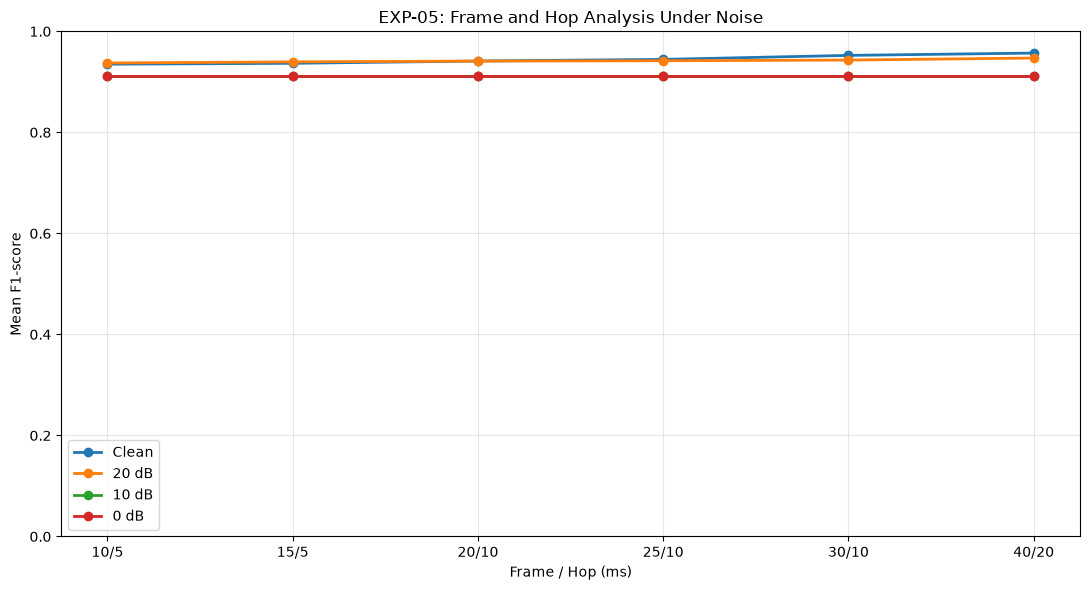

In [11]:
plt.figure(figsize=(11, 6))

for condition in noise_conditions:

    subset = noise_df[
        noise_df["Condition"] == condition
    ]

    labels = [
        f"{f}/{h}"
        for f, h in zip(
            subset["Frame (ms)"],
            subset["Hop (ms)"]
        )
    ]

    plt.plot(
        labels,
        subset["Mean F1"],
        marker="o",
        linewidth=2,
        label=condition
    )

plt.title(
    "EXP-05: Frame and Hop Analysis Under Noise"
)

plt.xlabel("Frame / Hop (ms)")
plt.ylabel("Mean F1-score")

plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [12]:
error_analysis = noise_df[
    noise_df["Condition"].isin(["10 dB", "0 dB"])
][
    [
        "Condition",
        "Frame (ms)",
        "Hop (ms)",
        "Mean Precision",
        "Mean Recall",
        "Total FP",
        "Total FN"
    ]
]

print(
    error_analysis.round(3).to_string(index=False)
)

Condition  Frame (ms)  Hop (ms)  Mean Precision  Mean Recall  Total FP  Total FN
    10 dB          10         5           0.844          1.0       352         0
    10 dB          15         5           0.844          1.0       352         0
    10 dB          20        10           0.844          1.0       352         0
    10 dB          25        10           0.844          1.0       352         0
    10 dB          30        10           0.844          1.0       352         0
    10 dB          40        20           0.844          1.0       352         0
     0 dB          10         5           0.844          1.0       352         0
     0 dB          15         5           0.844          1.0       352         0
     0 dB          20        10           0.844          1.0       352         0
     0 dB          25        10           0.844          1.0       352         0
     0 dB          30        10           0.844          1.0       352         0
     0 dB          40       

In [13]:
frame_configs = [
    (10, 10),
    (15, 10),
    (20, 10),
    (25, 10),
    (30, 10),
    (40, 10)
]

hop_configs = [
    (30, 5),
    (30, 10),
    (30, 15),
    (30, 20),
    (30, 30)
]

In [14]:
def run_controlled_experiment(
    configurations,
    records,
    threshold=0.005
):

    results = []

    for frame_ms, hop_ms in configurations:

        metrics = []

        for record in records:

            result = evaluate_configuration(
                record,
                frame_ms,
                hop_ms,
                threshold
            )

            metrics.append(result)

        results.append({
            "Frame": frame_ms,
            "Hop": hop_ms,

            "Mean Precision": np.mean([
                m["Precision"] for m in metrics
            ]),

            "Mean Recall": np.mean([
                m["Recall"] for m in metrics
            ]),

            "Mean F1": np.mean([
                m["F1"] for m in metrics
            ]),

            "Total FP": sum(
                m["FP"] for m in metrics
            ),

            "Total FN": sum(
                m["FN"] for m in metrics
            ),

            "Mean Time (ms)": np.mean([
                m["Processing Time"]
                for m in metrics
            ]) * 1000,

            "Total Frames": sum([
                m["Frame Count"]
                for m in metrics
            ])
        })

    return pd.DataFrame(results)

In [15]:
frame_df = run_controlled_experiment(
    frame_configs,
    development_records
)

print(
    frame_df.round(4).to_string(index=False)
)

 Frame  Hop  Mean Precision  Mean Recall  Mean F1  Total FP  Total FN  Mean Time (ms)  Total Frames
    10   10          0.9470       0.9245   0.9347       107       239          0.5365         11943
    15   10          0.9471       0.9318   0.9386       110       209          0.4903         11937
    20   10          0.9483       0.9354   0.9412       111       200          0.6681         11928
    25   10          0.9488       0.9413   0.9445       111       183          0.8080         11922
    30   10          0.9501       0.9557   0.9524       110       148          0.9205         11913
    40   10          0.9492       0.9613   0.9548       111       124          1.2618         11898


In [16]:
hop_df = run_controlled_experiment(
    hop_configs,
    development_records
)

print(
    hop_df.round(4).to_string(index=False)
)

 Frame  Hop  Mean Precision  Mean Recall  Mean F1  Total FP  Total FN  Mean Time (ms)  Total Frames
    30    5          0.9503       0.9517   0.9506       109       151          1.6964         23820
    30   10          0.9501       0.9557   0.9524       110       148          0.6875         11913
    30   15          0.9489       0.9534   0.9507       112       155          0.6139          7946
    30   20          0.9505       0.9484   0.9489       110       166          0.4922          5959
    30   30          0.9501       0.9468   0.9478       107       165          0.3409          3976


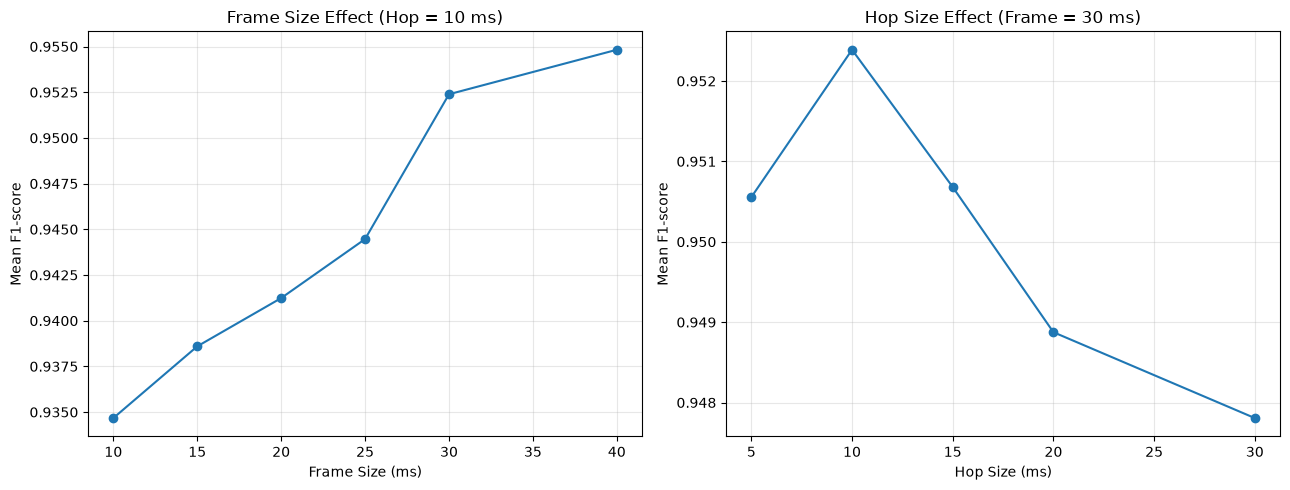

In [17]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(13, 5)
)

axes[0].plot(
    frame_df["Frame"],
    frame_df["Mean F1"],
    marker="o"
)

axes[0].set_title(
    "Frame Size Effect (Hop = 10 ms)"
)

axes[0].set_xlabel("Frame Size (ms)")
axes[0].set_ylabel("Mean F1-score")
axes[0].grid(alpha=0.3)

axes[1].plot(
    hop_df["Hop"],
    hop_df["Mean F1"],
    marker="o"
)

axes[1].set_title(
    "Hop Size Effect (Frame = 30 ms)"
)

axes[1].set_xlabel("Hop Size (ms)")
axes[1].set_ylabel("Mean F1-score")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
selected_configs = [
    (25, 10),
    (30, 10),
    (40, 10)
]

final_results = []

for frame_ms, hop_ms in selected_configs:

    metrics = []

    for record in evaluation_records:

        result = evaluate_configuration(
            record,
            frame_ms,
            hop_ms,
            threshold=0.005
        )

        metrics.append(result)

    tp = sum(m["TP"] for m in metrics)
    tn = sum(m["TN"] for m in metrics)
    fp = sum(m["FP"] for m in metrics)
    fn = sum(m["FN"] for m in metrics)

    final_results.append({
        "Frame": frame_ms,
        "Hop": hop_ms,

        "Mean Precision": np.mean([
            m["Precision"] for m in metrics
        ]),

        "Mean Recall": np.mean([
            m["Recall"] for m in metrics
        ]),

        "Mean F1": np.mean([
            m["F1"] for m in metrics
        ]),

        "Total TP": tp,
        "Total TN": tn,
        "Total FP": fp,
        "Total FN": fn,

        "Mean Time (ms)": np.mean([
            m["Processing Time"]
            for m in metrics
        ]) * 1000,

        "Total Frames": sum(
            m["Frame Count"]
            for m in metrics
        )
    })

final_frame_df = pd.DataFrame(
    final_results
)

print(
    final_frame_df.round(4).to_string(index=False)
)

 Frame  Hop  Mean Precision  Mean Recall  Mean F1  Total TP  Total TN  Total FP  Total FN  Mean Time (ms)  Total Frames
    25   10          0.9587       0.9406   0.9490      2389       194        84       149          0.9902          9796
    30   10          0.9593       0.9461   0.9521      2405       193        85       133          0.5723          9789
    40   10          0.9583       0.9564   0.9569      2427       187        91       111          0.9832          9774


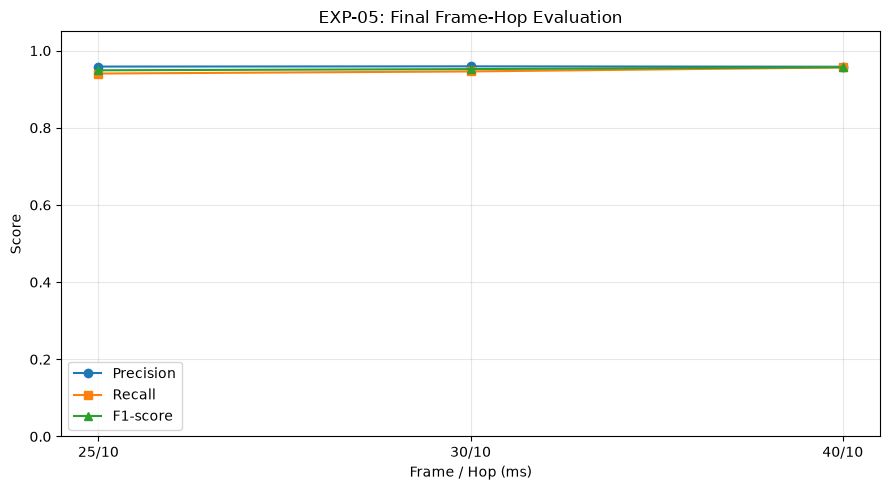

In [19]:
labels = [
    f"{f}/{h}"
    for f, h in selected_configs
]

plt.figure(figsize=(9, 5))

plt.plot(
    labels,
    final_frame_df["Mean Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    labels,
    final_frame_df["Mean Recall"],
    marker="s",
    label="Recall"
)

plt.plot(
    labels,
    final_frame_df["Mean F1"],
    marker="^",
    label="F1-score"
)

plt.title(
    "EXP-05: Final Frame-Hop Evaluation"
)

plt.xlabel("Frame / Hop (ms)")
plt.ylabel("Score")

plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()